In [ ]:
!pip install Sastrawi gensim scikit-learn pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Ilhammm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import re
import random

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.corpora import Dictionary
from gensim.models import LdaModel, TfidfModel, CoherenceModel

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
df = pd.read_csv('C:\\Users\\Ilhammm\\Downloads\Data_LDA_TextMining_W9.csv')
df.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1.567300e+18,1.567300e+18,2022-09-06 23:57:21 UTC,9/6/2022,23:57:21,0,1.054330e+18,galihgumy_,Doom,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
1,1.567300e+18,1.566930e+18,2022-09-06 23:57:11 UTC,9/6/2022,23:57:11,0,1.563000e+18,angelngguyu,ANGEL NGGUYU,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'CNNIndonesia', 'name': 'CNN ...",NaN,NaN,NaN,NaN
2,1.567300e+18,1.567300e+18,2022-09-06 23:51:30 UTC,9/6/2022,23:51:30,0,6.807762e+07,hyungahim,Jefhim Nichol,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,1.567300e+18,1.567300e+18,2022-09-06 23:51:16 UTC,9/6/2022,23:51:16,0,1.086160e+18,kopipolitik1,kopipolitik,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,1.567300e+18,1.567290e+18,2022-09-06 23:39:54 UTC,9/6/2022,23:39:54,0,1.459150e+18,viewtidsarn,laila hamdan,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN


In [ ]:
# Mengambil kolom tweet
texts = df['tweet'].astype(str).tolist()
len(texts)

10536

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ── Stop word dari Sastrawi ──────────────────────────────────────────
stop_factory = StopWordRemoverFactory()
stopwords_sastrawi = set(stop_factory.get_stop_words())

# ── Stop word manual (kata tidak informatif konteks tweet/sosmed) ────
stopwords_manual = {

    # Singkatan & slang sosmed
    'yg', 'dgn', 'utk', 'krn', 'karna', 'tp', 'tapi',
    'jd', 'sdh', 'udah', 'udh', 'dah', 'blm', 'belum',
    'bgt', 'banget', 'bngt', 'jg', 'sm',
    'klo', 'kalo', 'kl', 'mw', 'bs',
    'sih', 'aja', 'dong', 'deh', 'lah', 'lho', 'nih',
    'nah', 'kan', 'ya', 'yah', 'yo', 'iya', 'iye', 'ok', 'oke',

    # Kata ganti & sapaan
    'gue', 'gua', 'gw', 'aku', 'saya', 'kamu', 'lo', 'lu', 'dia',
    'kita', 'kami', 'mereka', 'kak', 'mas', 'mba', 'mbak', 'pak',
    'kalian', 'anda', 'nya',

    # Kata kerja & kata sifat umum (tidak spesifik topik)
    'ada', 'tidak', 'ga', 'gak', 'nggak', 'enggak', 'tak', 'bukan',
    'lagi', 'sudah', 'sedang', 'akan', 'telah', 'pernah',
    'buat', 'banyak', 'baru', 'lama', 'semua', 'mana', 'siapa',
    'gimana', 'kenapa', 'apa', 'kapan', 'tau', 'tahu',
    'kata', 'bilang', 'minta', 'bisa', 'perlu', 'harus',
    'dulu', 'terus', 'kali', 'kok', 'tdk',

    # Kata hubung & preposisi
    'dan', 'atau', 'di', 'ke', 'dari', 'untuk', 'dengan', 'yang',
    'pada', 'dalam', 'oleh', 'atas', 'bawah', 'tentang', 'setelah',
    'sama', 'juga', 'jadi', 'karena', 'kalau', 'mau', 'saja',
    'itu', 'ini', 'satu', 'dua', 'tiga',

    # Noise tweet & sosmed
    'rt', 'via', 'amp', 'http', 'https', 'www', 'co', 'id',
    'pic', 'twitter', 'instagram', 'ig', 'fb', 'follow', 'like',
    'share', 'retweet', 'tweetnya', 'thread',

    # Kata noise dari hasil topik — tidak membedakan topik
    # (muncul di hampir semua topik → tidak informatif)
    'nya',      # akhiran yang lolos stemming
    'gin',      # artefak stemming / noise
    'den',      # noise
    'cuk',      # noise/slang kasar
    'ato',      # singkatan "atau"
    'noh',      # partikel percakapan
    'set',      # noise
    'pura',     # konteks tidak relevan (pura-pura)
    'mulu',     # slang "melulu" → tidak informatif
    'ngeri',    # ekspresi umum
    'mending',  # ekspresi umum
    'koar',     # ekspresi umum
    'iseng',    # ekspresi umum
    'minat',    # ekspresi umum
    'keras',    # ekspresi umum
    'wkwkkw', 'wkwk', 'wkkw', 'haha', 'hehe', 'xixi', 'hahaha',  # tawa
    'mpud', 'pratama', 'persadha', 'ucup',  # nama orang / noise spesifik
    'bungkus', 'goreng', 'nasi',  # noise tidak relevan
    'telpon', 'nelpon', 'nomer', 'pindah',  # noise topik tidak relevan
    'selebew', 'slebew', 'ngurusin', 'urusin',  # slang/noise
    'hari', 'isu',  # terlalu umum
    'sendiri', 'diri',  # terlalu umum
    'orang', 'warga', 'masyarakat' # terlalu umum untuk data ini
}

# ── Gabungkan kedua stop word list ──────────────────────────────────
stopwords = stopwords_sastrawi | stopwords_manual
print(f'Total stop words: {len(stopwords)} '
      f'(Sastrawi: {len(stopwords_sastrawi)}, Manual tambahan: {len(stopwords_manual - stopwords_sastrawi)})')


Total stop words: 271 (Sastrawi: 123, Manual tambahan: 148)


PREPROCESSING (SASTRAWI)

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Hapus URL, mention, karakter non-huruf
    text = re.sub(r'http\S+|@\S+|[^a-zA-Z\s]', '', text)
    words = text.split()
    # 3. Filter stop word (Sastrawi + manual)
    words = [w for w in words if w not in stopwords]
    # 4. Stemming Sastrawi + filter pendek
    words = [stemmer.stem(w) for w in words if len(w) > 2]
    # 5. Hapus hasil stem yang masuk stop word
    words = [w for w in words if w not in stopwords]
    return words

docs = [preprocess(t) for t in texts]
docs[:3]


[['besok',
  'mah',
  'kerja',
  'tri',
  'tes',
  'ganti',
  'tuh',
  'bas',
  'projek',
  'biar',
  'kerja',
  'becus',
  'colong',
  'malu',
  'atuh',
  'status',
  'tri',
  'kominfo',
  'data',
  'bocor'],
 ['foto',
  'syur',
  'cepat',
  'direspon',
  'gilir',
  'data',
  'nik',
  'bocor',
  'kedodoran'],
 ['data',
  'duduk',
  'bocor',
  'kominfo',
  'ragelem',
  'disalahne',
  'cek',
  'daei',
  'skandal',
  'bbm',
  'dimundakne',
  'tibake',
  'meski',
  'opini',
  'pecah',
  'sek',
  'onok',
  'seng',
  'tetep',
  'bahas',
  'bocor',
  'data',
  'jurus',
  'ultimate',
  'pinangki',
  'napi',
  'tipikor',
  'lepas',
  'tahun',
  'total',
  'hukum',
  'tahun']]

DICTIONARY & CORPUS (GENSIM)

In [ ]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus_bow = [dictionary.doc2bow(doc) for doc in docs]

In [ ]:
# corpus TF-IDF
tfidf_model = TfidfModel(corpus_bow)
corpus_tfidf = tfidf_model[corpus_bow]

LDA GENSiM (BoW & TF-IDF)

In [ ]:
k_values = [5, 10, 15, 20, 25, 30]

results_gensim = []

for k in k_values:
    lda = LdaModel(corpus=corpus_bow, id2word=dictionary, num_topics=k, random_state=42, passes=20, iterations=200)

    topics = [[word for word, _ in lda.show_topic(i, topn=10)] for i in range(k)]

    cm = CoherenceModel(topics=topics, texts=docs, dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()

    results_gensim.append((k, score))
    print(f"K={k}, Coherence={score}")

K=5, Coherence=0.4858083019261697
K=10, Coherence=0.4855652030924039
K=15, Coherence=0.46366048700829715
K=20, Coherence=0.41319621541389645
K=25, Coherence=0.4009463097419806
K=30, Coherence=0.36452753972124724


In [ ]:
# LDA Gensim TF-IDF
results_gensim_tfidf = []

for k in k_values:
    lda = LdaModel(corpus=corpus_tfidf, id2word=dictionary, num_topics=k, random_state=42, passes=20, iterations=200)

    topics = [[word for word, _ in lda.show_topic(i, topn=10)] for i in range(k)]

    cm = CoherenceModel(topics=topics, texts=docs, dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()

    results_gensim_tfidf.append((k, score))
    print(f"K={k}, Coherence={score}")

K=5, Coherence=0.41308381730547916
K=10, Coherence=0.3741670404748546
K=15, Coherence=0.4334483597428746
K=20, Coherence=0.3837980357404043
K=25, Coherence=0.37048241059559284
K=30, Coherence=0.3682962123443703


LDA SCIKIT-LEARN (BoW)

In [ ]:
# Vectorisasi BoW
texts_joined = [" ".join(doc) for doc in docs]

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(texts_joined)

In [ ]:
# LDA sklearn BoW + coherence
results_sklearn_bow = []

for k in k_values:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=50,
        learning_method='batch',
        n_jobs=-1
    )

    lda.fit(X_bow)

    words = vectorizer.get_feature_names_out()

    topics = []
    for topic in lda.components_:
        top_words = [words[i] for i in topic.argsort()[-10:]]
        topics.append(top_words[::-1])

    cm = CoherenceModel(
        topics=topics,
        texts=docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = cm.get_coherence()

    results_sklearn_bow.append((k, score))
    print(f"K={k}, Coherence={score}")

K=5, Coherence=0.6281133056791216
K=10, Coherence=0.5473395019457705
K=15, Coherence=0.5118339520203893
K=20, Coherence=0.48978431896039226
K=25, Coherence=0.48246344019534493
K=30, Coherence=0.49407931807896904


LDA SCIKIT-LEARN (TF-IDF)

In [ ]:
# Vectorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(texts_joined)

In [ ]:
# LDA sklearn TF-IDF + coherence
results_sklearn_tfidf = []

for k in k_values:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=50,
        learning_method='batch',
        n_jobs=-1
    )

    lda.fit(X_tfidf)

    words = tfidf_vectorizer.get_feature_names_out()

    topics = []
    for topic in lda.components_:
        top_words = [words[i] for i in topic.argsort()[-10:]]
        topics.append(top_words[::-1])

    cm = CoherenceModel(
        topics=topics,
        texts=docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = cm.get_coherence()

    results_sklearn_tfidf.append((k, score))
    print(f"K={k}, Coherence={score}")

K=5, Coherence=0.594054012892262
K=10, Coherence=0.4133343878255749
K=15, Coherence=0.43756802612238344
K=20, Coherence=0.416947130156327
K=25, Coherence=0.430666790879632
K=30, Coherence=0.4297465958684251


LDA GIBBS SAMPLING (MANUAL)

In [ ]:
# Persiapan Gibbs Sampling
vocab = list(set(word for doc in docs for word in doc))
word2id = {w:i for i,w in enumerate(vocab)}
id2word = {i:w for w,i in word2id.items()}

docs_id = [[word2id[w] for w in doc] for doc in docs]

D = len(docs)
V = len(vocab)

alpha = 0.5
beta = 0.01
iterations = 200

In [ ]:
# Fungsi LDA Gibbs + coherence
def lda_gibbs(K):
    n_dk = np.zeros((D, K))
    n_kw = np.zeros((K, V))
    n_k = np.zeros(K)
    z_dn = []

    for d, doc in enumerate(docs_id):
        z_n = []
        for w in doc:
            k = random.randint(0, K-1)
            z_n.append(k)
            n_dk[d,k]+=1
            n_kw[k,w]+=1
            n_k[k]+=1
        z_dn.append(z_n)

    for it in range(iterations):
        for d, doc in enumerate(docs_id):
            for i,w in enumerate(doc):
                k_old = z_dn[d][i]

                n_dk[d,k_old]-=1
                n_kw[k_old,w]-=1
                n_k[k_old]-=1

                p = (n_dk[d]+alpha)*(n_kw[:,w]+beta)/(n_k+V*beta)
                p = p/p.sum()

                k_new = np.random.choice(K,p=p)

                z_dn[d][i]=k_new
                n_dk[d,k_new]+=1
                n_kw[k_new,w]+=1
                n_k[k_new]+=1

    phi = (n_kw+beta)/(n_k[:,None]+V*beta)

    topics=[]
    for k in range(K):
        top_words = np.argsort(phi[k])[-10:]
        topics.append([id2word[i] for i in top_words[::-1]])

    cm = CoherenceModel(topics=topics, texts=docs, dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

In [ ]:
# Evaluasi Gibbs
results_gibbs = []

for k in k_values:
    score = lda_gibbs(k)
    results_gibbs.append((k, score))
    print(f"K={k}, Coherence={score}")

K=5, Coherence=0.6058994149694538
K=10, Coherence=0.5882461148060659
K=15, Coherence=0.5615763507525073
K=20, Coherence=0.5637620246106623
K=25, Coherence=0.5398617000848199
K=30, Coherence=0.5395235175412084


MENENTUKAN K TERBAIK

In [ ]:
# Menampilkan hasil terbaik tiap metode
def best_result(results, name):
    best = max(results, key=lambda x: x[1])
    print(f"{name} terbaik: K={best[0]}, Coherence={best[1]}")

best_result(results_gensim, "Gensim BoW")
best_result(results_gensim_tfidf, "Gensim TF-IDF")
best_result(results_sklearn_bow, "Sklearn BoW")
best_result(results_sklearn_tfidf, "Sklearn TF-IDF")
best_result(results_gibbs, "Gibbs Sampling")

Gensim BoW terbaik: K=5, Coherence=0.4858083019261697
Gensim TF-IDF terbaik: K=15, Coherence=0.4334483597428746
Sklearn BoW terbaik: K=5, Coherence=0.6281133056791216
Sklearn TF-IDF terbaik: K=5, Coherence=0.594054012892262
Gibbs Sampling terbaik: K=5, Coherence=0.6058994149694538


# MODEL TERBAIK + CETAK TOPIK

#####GENSiM (BoW & TF-IDF)

In [ ]:
def show_best_gensim(corpus, k_best, name):
    print(f"\n{name} (K={k_best})\n")

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k_best,
        random_state=42,
        passes=20,
        iterations=200
    )

    for i in range(k_best):
        words = lda.show_topic(i, topn=10)
        print(f"Topik {i+1}: {[w for w,_ in words]}")

SCIKIT-LEARN

In [ ]:
def show_best_sklearn(X, vectorizer, k_best, name):
    print(f"\n{name} (K={k_best})\n")

    lda = LatentDirichletAllocation(
        n_components=k_best,
        random_state=42,
        max_iter=50,
        learning_method='batch',
        n_jobs=-1
    )
    lda.fit(X)

    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(lda.components_):
        top_words = [words[j] for j in topic.argsort()[-10:]]
        print(f"Topik {i+1}: {top_words[::-1]}")

GIBBS SAMPLING

In [ ]:
# Menampilkan topik Gibbs terbaik
def show_best_gibbs(K):
    print(f"\nGibbs Sampling (K={K})\n")

    n_dk = np.zeros((D, K))
    n_kw = np.zeros((K, V))
    n_k = np.zeros(K)
    z_dn = []

    for d, doc in enumerate(docs_id):
        z_n = []
        for w in doc:
            k = random.randint(0, K-1)
            z_n.append(k)
            n_dk[d,k]+=1
            n_kw[k,w]+=1
            n_k[k]+=1
        z_dn.append(z_n)

    for it in range(iterations):
        for d, doc in enumerate(docs_id):
            for i,w in enumerate(doc):
                k_old = z_dn[d][i]

                n_dk[d,k_old]-=1
                n_kw[k_old,w]-=1
                n_k[k_old]-=1

                p = (n_dk[d]+alpha)*(n_kw[:,w]+beta)/(n_k+V*beta)
                p = p/p.sum()

                k_new = np.random.choice(K,p=p)

                z_dn[d][i]=k_new
                n_dk[d,k_new]+=1
                n_kw[k_new,w]+=1
                n_k[k_new]+=1

    phi = (n_kw+beta)/(n_k[:,None]+V*beta)

    for k in range(K):
        top_words = np.argsort(phi[k])[-10:]
        print(f"Topik {k+1}: {[id2word[i] for i in top_words[::-1]]}")

In [ ]:
best_gensim_k = max(results_gensim, key=lambda x: x[1])[0]
best_gensim_tfidf_k = max(results_gensim_tfidf, key=lambda x: x[1])[0]
best_sklearn_bow_k = max(results_sklearn_bow, key=lambda x: x[1])[0]
best_sklearn_tfidf_k = max(results_sklearn_tfidf, key=lambda x: x[1])[0]
best_gibbs_k = max(results_gibbs, key=lambda x: x[1])[0]

----------

In [ ]:
show_best_gensim(corpus_bow, best_gensim_k, "Gensim BoW")
show_best_gensim(corpus_tfidf, best_gensim_tfidf_k, "Gensim TF-IDF")

show_best_sklearn(X_bow, vectorizer, best_sklearn_bow_k, "Sklearn BoW")
show_best_sklearn(X_tfidf, tfidf_vectorizer, best_sklearn_tfidf_k, "Sklearn TF-IDF")

show_best_gibbs(best_gibbs_k)


Gensim BoW (K=5)

Topik 1: ['negara', 'bjorka', 'pribadi', 'lindung', 'aman', 'hacker', 'perintah', 'rahasia', 'mahfud', 'penting']
Topik 2: ['rakyat', 'salah', 'jawab', 'tanggung', 'jaga', 'pribadi', 'pdp', 'nik', 'malah', 'ganti']
Topik 3: ['ktp', 'pribadi', 'cuma', 'nama', 'islamkaffah', 'malah', 'emang', 'tuh', 'perintah', 'kayak']
Topik 4: ['juta', 'sim', 'duga', 'kominfo', 'card', 'polri', 'registrasi', 'indonesia', 'jual', 'miliar']
Topik 5: ['naik', 'bbm', 'polisi', 'usang', 'bin', 'ikut', 'aplikasi', 'harga', 'kasus', 'cek']

Gensim TF-IDF (K=15)

Topik 1: ['tegas', 'digital', 'anggar', 'pilih', 'efek', 'lepas', 'elu', 'koruptor', 'anjir', 'jaman']
Topik 2: ['sering', 'ganti', 'password', 'arti', 'hoax', 'kerja', 'islam', 'tuh', 'ajar', 'gampang']
Topik 3: ['islamkaffah', 'negara', 'lindung', 'ktp', 'punya', 'pribadi', 'bukti', 'percaya', 'indo', 'mudah']
Topik 4: ['bin', 'datadata', 'serang', 'khawatir', 'beli', 'mungkin', 'bagaimana', 'sadar', 'ikut', 'klaim']
Topik 5: ['em

### Visualisasi Coherence Score

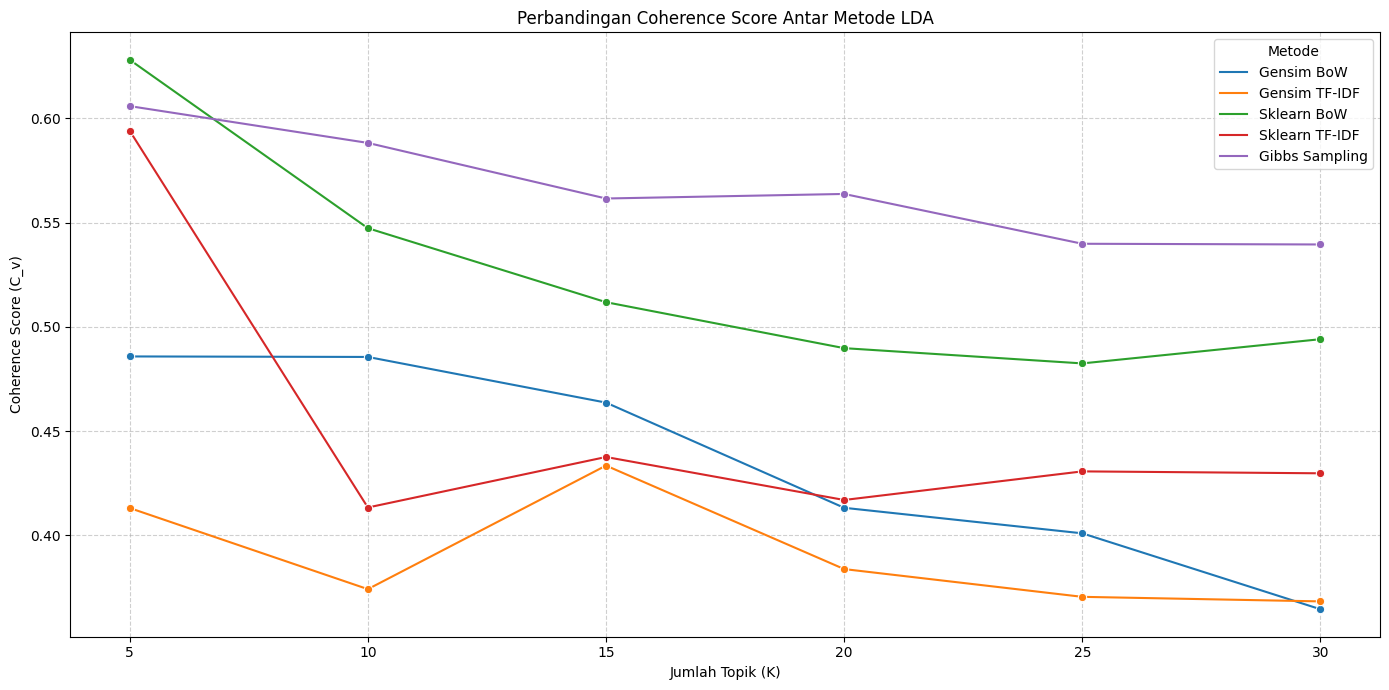

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = []

for k, score in results_gensim:
    plot_data.append({'K': k, 'Coherence Score': score, 'Method': 'Gensim BoW'})
for k, score in results_gensim_tfidf:
    plot_data.append({'K': k, 'Coherence Score': score, 'Method': 'Gensim TF-IDF'})
for k, score in results_sklearn_bow:
    plot_data.append({'K': k, 'Coherence Score': score, 'Method': 'Sklearn BoW'})
for k, score in results_sklearn_tfidf:
    plot_data.append({'K': k, 'Coherence Score': score, 'Method': 'Sklearn TF-IDF'})
for k, score in results_gibbs:
    plot_data.append({'K': k, 'Coherence Score': score, 'Method': 'Gibbs Sampling'})

plot_df = pd.DataFrame(plot_data)

# Create the plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, x='K', y='Coherence Score', hue='Method', marker='o')
plt.title('Perbandingan Coherence Score Antar Metode LDA')
plt.xlabel('Jumlah Topik (K)')
plt.ylabel('Coherence Score (C_v)')
plt.xticks(k_values) # Ensure all K values are shown on the x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Metode')
plt.tight_layout()
plt.show()